In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt

미분(Differential)

<img src="differential1.png" width="300" align="left" />

In [2]:
# diff1(미분할 함수, 미분할 값, Δx)
def diff1(f, x, h=1e-6):
    return (f(x + h) - f(x)) / h

미분(Differential): 대칭 파생

<img src="differential2.png" width="300" align="left" />

In [3]:
# diff2(미분할 함수, 미분할 값, Δx)
def diff2(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2 * h)

In [4]:
def f1(x):
    return x ** 2

In [5]:
print(diff1(f1, 1))
print(diff2(f1, 1))

2.0000009999243673
2.000000000002


In [6]:
f2 = lambda x: x ** 2

In [7]:
print(diff1(f2, 1))
print(diff2(f2, 1))

2.0000009999243673
2.000000000002


경사 하강법 클래스를 만든다.

In [8]:
# 경사 하강법 클래스, 옵티마이저
class Descent:
    def __init__(self, lr, h=1e-6):
        self.lr = lr # 학습율
        self.h = h # 수치 미분을 위해 지정하는 값, 작을수록 더 정교한 미분을 실행한다.
        
    def __str__(self):
        return f'경사 하강법(학습율 = {self.lr})'
    
    # 미분을 실행하는 함수
    def diff(self, f, x):
        return (f(x + self.h) - f(x - self.h)) / (2 * self.h)
    
    # 경사 하강법 업데이트 함수
    def update(self, f, x):
        dx = self.diff(f, x)
        return x - self.lr * dx

경사 하강법 실행하고 결과를 시각화 클래스를 만든다.

In [9]:
class OneVariableFunc:
    def __init__(self, func, optimizer):
        self.func = func # 최적화 할 함수
        self.optimizer = optimizer # 옵티마이저 <= 경사 하강법, 모멘텀
        
    # 옵티마이저를 실행하는 메소드
    def run(self, x, epoch):
        self.xs = [x]
        for i in range(epoch):
            self.xs.append(self.optimizer.update(self.func, self.xs[-1]))
        print('{}에서 시작해서 {}번 {}을(를) 적용한 결과는 {} 입니다.'.format(x, epoch, self.optimizer, self.xs[-1]))
            
    # 시각화 메소드
    def visualize(self, xs, xe):
        # 2차원(오차) 곡선 시각화
        x = np.linspace(xs, xe, int((xe - xs) * 100))
        y = [self.func(i) for i in x]
        plt.plot(x, y, 'r--')
        # 경사 하강법으로 이동하는 위치 시각화
        ys = [self.func(i) for i in self.xs]
        plt.plot(self.xs, ys, 'go')
        plt.show()
        
    # 경사 하강법을 실행한 히스토리를 출력하는 함수
    def history(self):
        for i in range(len(self.xs[1:])):
            print('{:3d}번 {}을(를) 적용한 결과는 {:10.8f} 입니다.'.format(i + 1, self.optimizer, self.xs[i + 1]))

경사 하강법 실행

In [10]:
# 경사 하강법 클래스의 객체를 학습율 0.01을 전달해서 생성한다.
optimizer = Descent(0.05)
print(optimizer)
f = lambda x: x ** 2 # 미분할 함수
# 경사 하강법을 적용한 결과를 시각화 하는 클래스 객체 생성
ex = OneVariableFunc(f, optimizer)
ex.run(2.5, 50)

경사 하강법(학습율 = 0.05)
2.5에서 시작해서 50번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.012884438018285127 입니다.


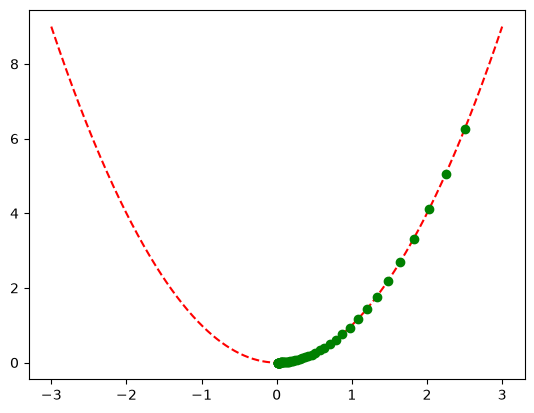

In [11]:
ex.visualize(-3, 3)

In [12]:
ex.history()

  1번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 2.25000000 입니다.
  2번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 2.02500000 입니다.
  3번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 1.82250000 입니다.
  4번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 1.64025000 입니다.
  5번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 1.47622500 입니다.
  6번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 1.32860250 입니다.
  7번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 1.19574225 입니다.
  8번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 1.07616802 입니다.
  9번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.96855122 입니다.
 10번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.87169610 입니다.
 11번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.78452649 입니다.
 12번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.70607384 입니다.
 13번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.63546646 입니다.
 14번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.57191981 입니다.
 15번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.51472783 입니다.
 16번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.46325505 입니다.
 17번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.41692954 입니다.
 18번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.37523659 입니다.
 19번 경사 하강법(학습율 = 0.05)을(를) 적용한 결과는 0.33771293 입니다.
 20번 경사 하강법(

경사 하강법(학습율 = 0.1)
2.5에서 시작해서 50번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 3.568119231780558e-05 입니다.


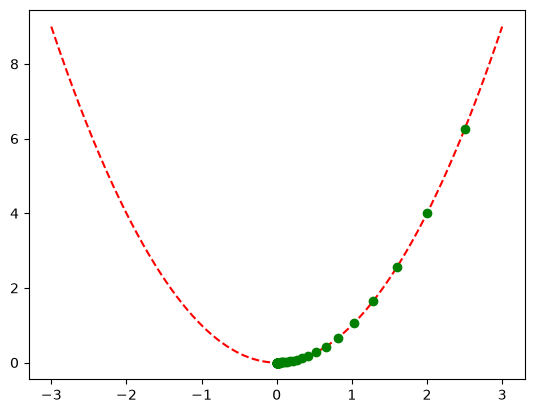

  1번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 2.00000000 입니다.
  2번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 1.60000000 입니다.
  3번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 1.28000000 입니다.
  4번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 1.02400000 입니다.
  5번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.81920000 입니다.
  6번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.65536000 입니다.
  7번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.52428800 입니다.
  8번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.41943040 입니다.
  9번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.33554432 입니다.
 10번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.26843546 입니다.
 11번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.21474836 입니다.
 12번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.17179869 입니다.
 13번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.13743895 입니다.
 14번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.10995116 입니다.
 15번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.08796093 입니다.
 16번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.07036874 입니다.
 17번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.05629500 입니다.
 18번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.04503600 입니다.
 19번 경사 하강법(학습율 = 0.1)을(를) 적용한 결과는 0.03602880 입니다.
 20번 경사 하강법(학습율 = 0.1)을(를) 적용한 

In [13]:
optimizer = Descent(0.1)
print(optimizer)
f = lambda x: x ** 2
ex = OneVariableFunc(f, optimizer)
ex.run(2.5, 50)
ex.visualize(-3, 3)
ex.history()

경사 하강법(학습율 = 1)
2.5에서 시작해서 50번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.500000035971226 입니다.


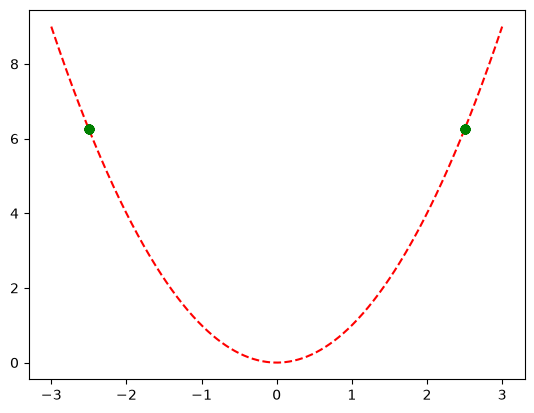

  1번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000000 입니다.
  2번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000000 입니다.
  3번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000000 입니다.
  4번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000000 입니다.
  5번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000000 입니다.
  6번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000000 입니다.
  7번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000000 입니다.
  8번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000001 입니다.
  9번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000001 입니다.
 10번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000001 입니다.
 11번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000001 입니다.
 12번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000001 입니다.
 13번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000001 입니다.
 14번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000001 입니다.
 15번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000001 입니다.
 16번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000001 입니다.
 17번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000001 입니다.
 18번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000001 입니다.
 19번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 -2.50000001 입니다.
 20번 경사 하강법(학습율 = 1)을(를) 적용한 결과는 2.50000002 입니다.
 21번 경사 하강

In [14]:
optimizer = Descent(1)
print(optimizer)
f = lambda x: x ** 2
ex = OneVariableFunc(f, optimizer)
ex.run(2.5, 50)
ex.visualize(-3, 3)
ex.history()

경사 하강법(학습율 = 0.001)
2.5에서 시작해서 50번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.261867044979269 입니다.


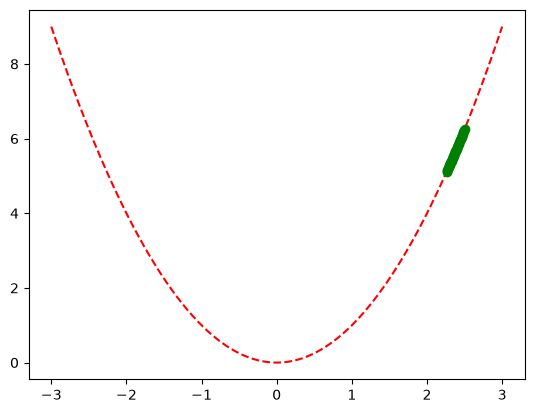

  1번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.49500000 입니다.
  2번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.49001000 입니다.
  3번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.48502998 입니다.
  4번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.48005992 입니다.
  5번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.47509980 입니다.
  6번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.47014960 입니다.
  7번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.46520930 입니다.
  8번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.46027888 입니다.
  9번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.45535833 입니다.
 10번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.45044761 입니다.
 11번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.44554671 입니다.
 12번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.44065562 입니다.
 13번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.43577431 입니다.
 14번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.43090276 입니다.
 15번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.42604095 입니다.
 16번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.42118887 입니다.
 17번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.41634649 입니다.
 18번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.41151380 입니다.
 19번 경사 하강법(학습율 = 0.001)을(를) 적용한 결과는 2.4066907

In [15]:
optimizer = Descent(0.001)
print(optimizer)
f = lambda x: x ** 2
ex = OneVariableFunc(f, optimizer)
ex.run(2.5, 50)
ex.visualize(-3, 3)
ex.history()

가운데 평탄한(기울기가 0인) 구간이 있는 함수

In [35]:
def ff(x):
    if x > 1:
        return x ** 2
    elif x > 0.2:
        return 1
    else:
        return 20 * x ** 2

2.5에서 시작해서 50번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 0.98705076749944 입니다.


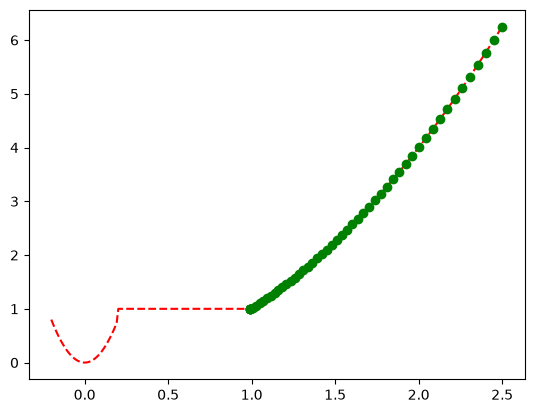

  1번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.45000000 입니다.
  2번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.40100000 입니다.
  3번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.35298000 입니다.
  4번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.30592040 입니다.
  5번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.25980199 입니다.
  6번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.21460595 입니다.
  7번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.17031383 입니다.
  8번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.12690756 입니다.
  9번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.08436941 입니다.
 10번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.04268202 입니다.
 11번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.00182838 입니다.
 12번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.96179181 입니다.
 13번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.92255597 입니다.
 14번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.88410485 입니다.
 15번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.84642276 입니다.
 16번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.80949430 입니다.
 17번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.77330442 입니다.
 18번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.73783833 입니다.
 19번 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.70308156 입니다.
 20번 경사 하강법(

In [40]:
optimizer = Descent(0.01)
ex = OneVariableFunc(ff, optimizer)
ex.run(2.5, 50)
ex.visualize(-0.2, 2.5)
ex.history()

경사 하강법 모멘텀 클래스를 만든다.

In [41]:
class Momentum:
    def __init__(self, mo, lr, h=1e-6):
        self.previous = 0 # 이전에 얼마나 움직였나 기억하는 변수
        self.mo = mo # 관성 계수, 보통 0.8이나 0.9 정도를 사용한다.
        self.lr = lr
        self.h = h
        
    def __str__(self):
        return f'모멘텀 경사 하강법(학습율 = {self.lr})'
    
    def diff(self, f, x):
        # return (f(x + self.h) - f(x - self.h)) / (2 * self.h)
        return (f(x + self.h) - f(x)) / self.h
    
    def update(self, f, x):
        # dx = self.diff(f, x) # 경사 하강법
        # 이전에 움직인 거리를 계산한다.
        dx = self.previous * self.mo - self.lr * self.diff(f, x)
        # 이전에 움직인 거리를 저장한다.
        self.previous = dx
        # return x - self.lr * dx # 경사 하강법
        return x + dx

2.5에서 시작해서 15번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 -0.029871173415843305 입니다.


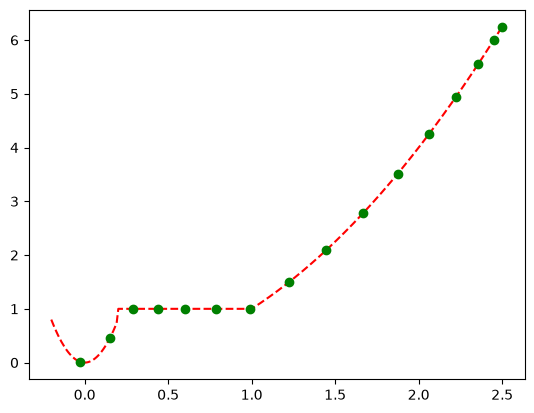

  1번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.44999999 입니다.
  2번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.35599997 입니다.
  3번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.22427994 입니다.
  4번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 2.06124631 입니다.
  5번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.87329111 입니다.
  6번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.66666559 입니다.
  7번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.44736930 입니다.
  8번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 1.22105525 입니다.
  9번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 0.99295148 입니다.
 10번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 0.78765810 입니다.
 11번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 0.60289405 입니다.
 12번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 0.43660640 입니다.
 13번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 0.28694752 입니다.
 14번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 0.15225453 입니다.
 15번 모멘텀 경사 하강법(학습율 = 0.01)을(를) 적용한 결과는 -0.02987117 입니다.


In [54]:
optimizer = Momentum(0.9, 0.01)
ex = OneVariableFunc(ff, optimizer)
ex.run(2.5, 15)
ex.visualize(-0.2, 2.5)
ex.history()